In [2]:
# #to fetch ic5o with header  run the bewlow  command in terminal 
# #head -n 1 ABL1_P00519_values.csv > ABL1_P00519_IC50_only.csv
# #grep "IC50" ABL1_P00519_values.csv >> ABL1_P00519_IC50_only.csv


import os
os.chdir('/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/ABL1')

import pandas as pd

# # Load both datasets
# df1 = pd.read_csv("ABL1_CHEMBL1862_IC50_chembl_Wsmile.csv")
# df2 = pd.read_csv("ABL1_P00519_IC50_only.csv")


# df2 = df2[["SMILES", "Affinity Value"]]
# df2.columns = ["smiles", "standard_value"]  # rename for consistency

# common_smiles = set(df1["smiles"]) & set(df2["smiles"])

# # Filter rows with common SMILES
# df1_common = df1[df1["smiles"].isin(common_smiles)][["smiles", "standard_value"]].rename(columns={"standard_value": "IC50_df1"})
# df2_common = df2[df2["smiles"].isin(common_smiles)][["smiles", "standard_value"]].rename(columns={"standard_value": "IC50_df2"})

# # Merge on SMILES
# merged = pd.merge(df1_common, df2_common, on="smiles")

# # print(merged)  # Show first 10 entries

# print(f"Number of common SMILES: {len(common_smiles)}")
# # print(list(common_smiles)[:10])  # Print first 10 for preview

# # # Combine the two datasets
# combined_df = pd.concat([df1, df2], ignore_index=True)
# combined_df


# # # Drop entries with missing SMILES or IC50
# combined_df = combined_df.dropna(subset=["smiles", "standard_value"])
# combined_df
# # # Convert IC50 values to numeric
# combined_df["standard_value"] = pd.to_numeric(combined_df["standard_value"], errors="coerce")
# # combined_df
# # # Drop any rows with NaNs in standard_value after conversion
# combined_df = combined_df.dropna(subset=["standard_value"])
# combined_df

# # # Keep only the entry with the lowest IC50 for each SMILES
# min_ic50_df = combined_df.loc[combined_df.groupby("smiles")["standard_value"].idxmin()]
# min_ic50_df
# # # Select only relevant columns
# final_df = min_ic50_df[["smiles", "standard_value"]].reset_index(drop=True)

# # # Save to a new CSV file
# final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)



In [3]:
import os
os.chdir('/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/ABL1')
final_df= pd.read_csv("dedeuplicated_combined_ic50.csv")
##check for duplication
# Ensure SMILES column is treated as string
final_df["smiles"] = final_df["smiles"].astype(str)

# Check for duplicates in the 'smiles' column
duplicates = final_df[final_df.duplicated("smiles", keep=False)]  # keep=False shows *all* duplicates

# Print number and preview of duplicates
print(f"Total duplicate SMILES entries: {len(duplicates)}")
print(duplicates.head())




Total duplicate SMILES entries: 0
Empty DataFrame
Columns: [smiles, standard_value, is_valid, label]
Index: []


In [4]:
final_df


,smiles,standard_value,is_valid,label
0,Brc1ccc(NC(=O)[C@@H]2C[C@@H](CN2)n2cc(nn2)-c2c...,5.5,True,1
1,Brc1ccc(NC(=O)[C@@H]2C[C@@H](CN2)n2cc(nn2)-c2c...,10.0,True,1
2,Brc1ccc(cc1)C(=O)N1CCN(CC1)C(=O)c1ccc(cc1)-c1c...,73.0,True,1
3,Brc1ccc(cc1)C(=O)N1CCN(CC1)C(=O)c1ccc(cc1)-c1n...,421.0,True,1
4,Brc1ccc2[nH]c-3c(CC(=O)Nc4ccccc-34)c2c1,350000.0,True,0
...,...,...,...,...
4615,c1csc(CNc2ccc3[nH]nc(-c4nc5cc(N6CCC(N7CCCCC7)C...,10.0,True,1
4616,c1n[nH]cc1-c1cnc2ncc(-c3cn[nH]c3)n2c1,440.0,True,1
4617,c1n[nH]cc1-c1cnc2ncc(cn12)-c1cn[nH]c1,440.0,True,1
4618,c1nc(N2CCC3(CCCCN3)CC2)c2nc[nH]c2n1,126000.0,True,0


In [5]:
from rdkit import Chem
import pandas as pd


# Check for invalid SMILES
def check_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None
final_df['is_valid'] = final_df['smiles'].apply(check_smiles)

# Report
invalid_smiles = final_df[~final_df['is_valid']]
print(f"Total SMILES: {len(final_df)}")
print(f"Invalid SMILES: {len(invalid_smiles)}")

if not invalid_smiles.empty:
    print("List of invalid SMILES:")
    print(invalid_smiles[['smiles']])
else:
    print("✅ All SMILES are valid.")


# remove the invalid using
final_df = final_df[final_df['is_valid']]
final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)

Total SMILES: 4620
Invalid SMILES: 0
✅ All SMILES are valid.


In [6]:
final_df

,smiles,standard_value,is_valid,label
0,Brc1ccc(NC(=O)[C@@H]2C[C@@H](CN2)n2cc(nn2)-c2c...,5.5,True,1
1,Brc1ccc(NC(=O)[C@@H]2C[C@@H](CN2)n2cc(nn2)-c2c...,10.0,True,1
2,Brc1ccc(cc1)C(=O)N1CCN(CC1)C(=O)c1ccc(cc1)-c1c...,73.0,True,1
3,Brc1ccc(cc1)C(=O)N1CCN(CC1)C(=O)c1ccc(cc1)-c1n...,421.0,True,0
4,Brc1ccc2[nH]c-3c(CC(=O)Nc4ccccc-34)c2c1,350000.0,True,0
...,...,...,...,...
4615,c1csc(CNc2ccc3[nH]nc(-c4nc5cc(N6CCC(N7CCCCC7)C...,10.0,True,1
4616,c1n[nH]cc1-c1cnc2ncc(-c3cn[nH]c3)n2c1,440.0,True,0
4617,c1n[nH]cc1-c1cnc2ncc(cn12)-c1cn[nH]c1,440.0,True,0
4618,c1nc(N2CCC3(CCCCN3)CC2)c2nc[nH]c2n1,126000.0,True,0


In [5]:
#classification actives/inactives

# 2) Convert IC50 column to numeric (in case there were strings)
final_df['standard_value'] = pd.to_numeric(final_df['standard_value'], errors='coerce')

# 3) Add classification column
final_df['label'] = (final_df['standard_value'] < 1000).astype(int)
# 1 = Active, 0 = Inactive


# 4) Quick sanity check
print(final_df[['standard_value', 'label']].head())

# 5) (Optional) Save back out
final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)


   standard_value  label
0             5.5      1
1            10.0      1
2            73.0      1
3           421.0      1
4        350000.0      0


In [7]:
# Count how many of each
counts = final_df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(final_df))

Inactives (0): 1500
Actives   (1): 3120
4620


In [ ]:
# #SMILE AUGMENTATION FOR TTBK
# from rdkit import Chem
# from rdkit.Chem import MolToSmiles
# import pandas as pd

# def random_smiles(smiles, n=5):
#     mol = Chem.MolFromSmiles(smiles)
#     return [MolToSmiles(mol, doRandom=True) for _ in range(n)]

# # Load your small-data TTBK DataFrame with columns: smiles, label
# ttbk_df = pd.read_csv("dedeuplicated_combined_ic50.csv")

# augmented_rows = []
# for _, row in ttbk_df.iterrows():
#     smi, lbl = row['smiles'], row['label']
#     for rnd_smi in random_smiles(smi, n=5):
#         augmented_rows.append({'smiles': rnd_smi, 'label': lbl})

# aug_df = pd.DataFrame(augmented_rows)
# # Combine with the original
# ttbk_augmented = pd.concat([ttbk_df, aug_df], ignore_index=True)
# ttbk_augmented.to_csv("trial.csv")



In [8]:
# Count how many of each
counts = aug_df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(aug_df))

NameError: name 'aug_df' is not defined

In [9]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

def load_and_clean(path):
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"ERROR loading data: {e}")
        return None
    if not {'smiles', 'label'}.issubset(df.columns):
        print(f"ERROR: Required columns missing: {df.columns.tolist()}")
        return None
    df = df.dropna(subset=['smiles', 'label'])
    df = df[df['smiles'].str.strip().ne('')].copy()
    df['label'] = pd.to_numeric(df['label'], errors='raise').astype(int)
    print(f"Loaded {len(df)} clean entries; labels: {sorted(df['label'].unique())}")
    return df

def validate_smiles(df, sample_n=500, threshold=0.9):
    smpls = df['smiles'].sample(min(sample_n, len(df)), random_state=42)
    valid = smpls.apply(lambda s: Chem.MolFromSmiles(s) is not None).mean()
    print(f"SMILES valid on sample: {valid:.1%}")
    if valid < threshold:
        df = df[df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)].copy()
        print(f"Filtered invalid SMILES; remaining: {len(df)}")
    return df

def split_and_test(df):
    y = df['label'].values
    min_cls = np.min(np.bincount(y))
    strat = y if min_cls >= 2 else None
    if strat is None:
        print("WARNING: Cannot stratify; some classes with <2 samples")
    X_train, X_test, y_train, y_test = train_test_split(
        df['smiles'].values, y, test_size=0.2, stratify=strat, random_state=42
    )
    ok = sum(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 2048) is not None 
             for s in X_train[:5])
    print(f"FP test: {ok}/5 successful")
    return X_train, X_test, y_train, y_test

def gen_fps(smiles, radius=2, nbits=2048):
    fps, idx = [], []
    for i, s in enumerate(smiles):
        m = Chem.MolFromSmiles(s)
        if m:
            bit = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            if bit:
                fps.append(np.array(bit))
                idx.append(i)
    return np.array(fps), idx

from collections import Counter

def apply_smote(X_fp, y, imbalance_thresh=0.5):
    class_counts = Counter(y)
    if len(class_counts) <= 1:
        print("Only one class present, skipping SMOTE")
        return X_fp, y

    majority_class = max(class_counts, key=class_counts.get)
    minority_class = min(class_counts, key=class_counts.get)
    ratio = class_counts[minority_class] / class_counts[majority_class]

    print(f"Class distribution before SMOTE: {dict(class_counts)}")
    
    if ratio < imbalance_thresh:
        print("Applying SMOTE...")
        minority_count = class_counts[minority_class]
        k_neighbors = min(5, max(1, minority_count - 1))  # ensure at least 1
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        return sm.fit_resample(X_fp, y)

    print("SMOTE not needed")
    return X_fp, y


def pipeline(path):
    df = load_and_clean(path)
    if df is None: return
    df = validate_smiles(df)
    X_train, X_test, y_train, y_test = split_and_test(df)
    X_tr_fp, tr_idx = gen_fps(X_train)
    if not len(X_tr_fp):
        print("ERROR: No valid fingerprints generated")
        return
    y_tr = y_train[tr_idx]
    X_train_bal, y_train_bal = apply_smote(X_tr_fp, y_tr)
    print(f"Train size: {len(y_tr)} → {len(y_train_bal)} after SMOTE")
    return {
        'df_clean': df,
        'X_train': X_train_bal, 'y_train': y_train_bal,
        'X_test': gen_fps(X_test)[0], 'y_test': y_test
    }

if __name__ == "__main__":
    print("Running pipeline...")
    res = pipeline("dedeuplicated_combined_ic50.csv")
    if res:
        print("Pipeline completed.")
        print(res['df_clean'][['smiles','label']].head())


Running pipeline...
Loaded 4620 clean entries; labels: [0, 1]
SMILES valid on sample: 100.0%
FP test: 5/5 successful
Class distribution before SMOTE: {1: 2496, 0: 1200}
Applying SMOTE...
Train size: 3696 → 4992 after SMOTE
Pipeline completed.
                                              smiles  label
0  Brc1ccc(NC(=O)[C@@H]2C[C@@H](CN2)n2cc(nn2)-c2c...      1
1  Brc1ccc(NC(=O)[C@@H]2C[C@@H](CN2)n2cc(nn2)-c2c...      1
2  Brc1ccc(cc1)C(=O)N1CCN(CC1)C(=O)c1ccc(cc1)-c1c...      1
3  Brc1ccc(cc1)C(=O)N1CCN(CC1)C(=O)c1ccc(cc1)-c1n...      1
4            Brc1ccc2[nH]c-3c(CC(=O)Nc4ccccc-34)c2c1      0


In [ ]:
# if res:
#     # Save cleaned dataset
#     res['df_clean'].to_csv("df_clean.csv", index=False)

#     # Save train and test features/labels as readable CSVs
#     pd.DataFrame(res['X_train']).to_csv("X_train.csv", index=False)
#     pd.DataFrame(res['y_train'], columns=["label"]).to_csv("y_train.csv", index=False)
#     pd.DataFrame(res['X_test']).to_csv("X_test.csv", index=False)
#     pd.DataFrame(res['y_test'], columns=["label"]).to_csv("y_test.csv", index=False)


In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(res['X_train'], res['y_train'])

# preds = model.predict(res['X_test'])
# print(classification_report(res['y_test'], preds))


              precision    recall  f1-score   support

           0       0.90      0.93      0.91       454
           1       0.93      0.90      0.91       470

    accuracy                           0.91       924
   macro avg       0.91      0.91      0.91       924
weighted avg       0.91      0.91      0.91       924



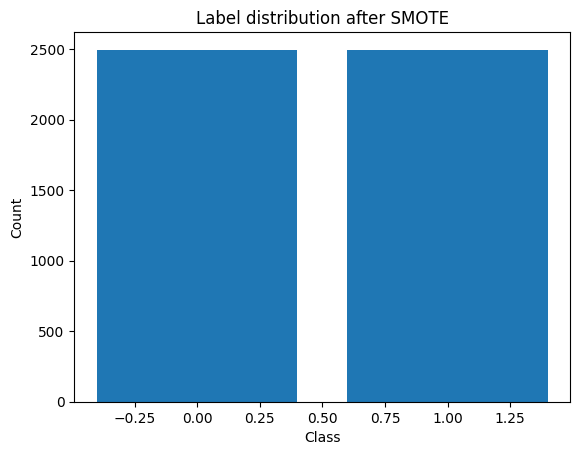

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(res['y_train'])
plt.bar(counts.keys(), counts.values())
plt.title("Label distribution after SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


CV F1-macro scores: [0.92424207 0.93290012 0.92748841 0.92423355 0.93613814]
Mean F1: 0.929 ± 0.005


XGB CV F1: 0.921 ± 0.006


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_score, recall_score,
    confusion_matrix, matthews_corrcoef
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# 1) PREPARE DATA — split into training and hold‑out test set
#    ensures test set is never used during parameter tuning
X_train = res['X_train']
y_train = res['y_train']
X_test = res['X_test']
y_test = res['y_test']
print(f"[DATA] {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")

# 2) DEFINE MODELS AND PARAMETER GRIDS for nested CV
#    each grid will be searched with a 5‑fold inner loop
models = {
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42,class_weights=[2141, 1091],task_type="GPU"),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(class_weight="balanced", probability=True, random_state=42))
    ]),
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    "NaiveBayes": GaussianNB(priors=[0.66, 0.34]),
    "XGBClassifier": XGBClassifier(
        scale_pos_weight=(1091/2141),
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}
param_grids = {
    "CatBoost": {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1],
        'iterations': [100, 300]
    },
    "SVM": {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto']
    },
    "KNN": {
        'knn__n_neighbors': [3, 5, 7],
        'knn__weights': ['uniform', 'distance']
    },
    "NaiveBayes": {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    "XGBClassifier": {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 300]
    }
}
print(f"[MODELS] Prepared {len(models)} estimators with parameter grids")

# 3) SET UP outer CV splitter for consistency (not used directly since we have a hold‑out test)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("[CV] Stratified 5‑fold configured for inner GridSearchCV")

def tune_and_evaluate(name, estimator, param_grid):
    """
    Performs:
    - Inner 5‑fold GridSearchCV on X_train/y_train to find best hyperparameters
    - Fits best estimator on full X_train
    - Evaluates on hold‑out X_test/y_test
    - Computes precision, recall (sensitivity), specificity, MCC
    - Saves the best model to disk
    """
    print(f"\n----- {name} Grid Search & Evaluation -----")
    
    # 3a) Inner grid search
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=outer_cv,
        n_jobs=1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    print(f"[GRID] Best params for {name}: {grid.best_params_}")
    print(f"[GRID] Best CV F1‑macro: {grid.best_score_:.3f}")
    
    # 3b) Fit best estimator on full training data
    best_model = grid.best_estimator_
    best_model.fit(X_train, y_train)
    print(f"[FIT] Trained {name} on all {X_train.shape[0]} training samples")
    
    # 3c) Predict on hold‑out test set
    y_pred = best_model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred, labels=[0, 1]
    ).ravel()
    
    # 3d) Compute metrics
    precision   = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    mcc         = matthews_corrcoef(y_test, y_pred)
    print(f"[TEST] Precision: {precision:.3f}")
    print(f"[TEST] Sensitivity (Recall): {sensitivity:.3f}")
    print(f"[TEST] Specificity: {specificity:.3f}")
    print(f"[TEST] MCC: {mcc:.3f}")
    
    # 3e) Save the best model
    fname = f"{name.lower()}_best_model.pkl"
    joblib.dump(best_model, fname)
    print(f"[SAVE] {name} model saved to {fname}")
    
    return {
        "Model": name,
        "Best_Params": grid.best_params_,
        "CV_F1_Macro": grid.best_score_,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "MCC": mcc
    }

# 4) RUN tuning & evaluation for all models
results = []
for name, model in models.items():
    grid_results = tune_and_evaluate(name, model, param_grids[name])
    results.append(grid_results)

# 5) SUMMARIZE all results
df_results = pd.DataFrame(results)
print("\n=== All Models Summary ===")
print(df_results.to_string(index=False))

[DATA] 4992 train samples, 924 test samples
[MODELS] Prepared 5 estimators with parameter grids
[CV] Stratified 5‑fold configured for inner GridSearchCV

----- CatBoost Grid Search & Evaluation -----
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[GRID] Best params for CatBoost: {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}
[GRID] Best CV F1‑macro: 0.929
[FIT] Trained CatBoost on all 4992 training samples
[TEST] Precision: 0.964
[TEST] Sensitivity (Recall): 0.936
[TEST] Specificity: 0.927
[TEST] MCC: 0.850
[SAVE] CatBoost model saved to catboost_best_model.pkl

----- SVM Grid Search & Evaluation -----
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[GRID] Best params for SVM: {'svc__C': 10, 'svc__gamma': 'auto'}
[GRID] Best CV F1‑macro: 0.907
[FIT] Trained SVM on all 4992 training samples
[TEST] Precision: 0.898
[TEST] Sensitivity (Recall): 0.942
[TEST] Specificity: 0.777
[TEST] MCC: 0.741
[SAVE] SVM model saved to svm_best_model.pkl

----- KNN Grid Se

In [12]:
#saving test and train dp
import numpy as np

# Assuming you already have these arrays ready
# X_train, X_test, y_train, y_test

np.savez_compressed(
    'train_test_data.npz',
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)
print("✅ Train/test data saved to train_test_data.npz")


✅ Train/test data saved to train_test_data.npz


In [13]:

##evaluation of the model
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef
)


# ── 1) LOAD OR RECONSTRUCT YOUR TEST SET ────────────────────────────────────────
# Option A: If you previously saved your test split, uncomment:
data = np.load('train_test_data.npz')
X_test, y_test = data['X_test'], data['y_test']
# X = np.concatenate([res['X_train'], res['X_test']])
# y = np.concatenate([res['y_train'], res['y_test']])
# _, X_test, _, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# 2) Load saved models
model_files = {
    'CatBoost':      'catboost_best_model.pkl',
    'SVM':           'svm_best_model.pkl',
    'KNN':           'knn_best_model.pkl',
    'NaiveBayes':    'naivebayes_best_model.pkl',
    'XGBClassifier': 'xgbclassifier_best_model.pkl'
}
models = {name: joblib.load(path) for name, path in model_files.items()}

# 3) Evaluate each model
print(f"{'Model':<12}  {'Prec':>5}  {'Rec':>5}  {'F1':>5}  {'Spec':>5}  {'MCC':>5}  {'ROC AUC':>7}")
print("-"*50)

for name, model in models.items():
    # 3a) Predictions and decision scores
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        # SVM decision_function → scale to [0,1]
        df = model.decision_function(X_test)
        y_score = (df - df.min()) / (df.max() - df.min())

    # 3b) Compute confusion‐matrix‐based metrics
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
    specificity = tn / (tn + fp)
    mcc         = matthews_corrcoef(y_test, y_pred)
    
    # 3c) ROC AUC
    roc_auc = roc_auc_score(y_test, y_score)
    
    # 3d) Print row
    print(f"{name:<12}  {precision:5.3f}  {recall:5.3f}  {f1:5.3f}  {specificity:5.3f}  {mcc:5.3f}  {roc_auc:7.3f}")


Model          Prec    Rec     F1   Spec    MCC  ROC AUC
--------------------------------------------------
CatBoost      0.964  0.936  0.950  0.927  0.850    0.970
SVM           0.898  0.942  0.919  0.777  0.741    0.947
KNN           0.946  0.896  0.920  0.893  0.770    0.935
NaiveBayes    0.896  0.832  0.863  0.800  0.612    0.839
XGBClassifier  0.954  0.893  0.922  0.910  0.779    0.962


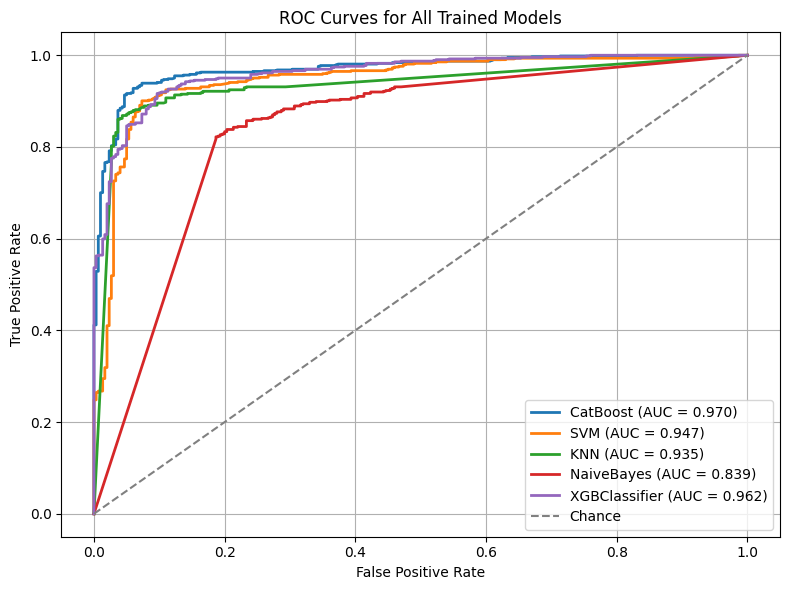

In [14]:
#ROC Generation
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# ── 1) LOAD OR RECONSTRUCT YOUR TEST SET ────────────────────────────────────────
# Option A: If you previously saved your test split, uncomment:
# data = np.load('test_data.npz')
# X_test, y_test = data['X_test'], data['y_test']
# data = np.load('train_data.npz')
# X_train, y_train = data['X_train'], data['y_train']


# Option B: Otherwise, rebuild it exactly as before:
# (This requires you to still have `res['X_train']`, etc. in memory)
# X = np.concatenate([res['X_train'], res['X_test']])
# y = np.concatenate([res['y_train'], res['y_test']])
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )
# print(f"[DATA] {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")


# ── 2) LOAD YOUR SAVED MODELS ───────────────────────────────────────────────────
model_files = {
    'CatBoost':      'catboost_best_model.pkl',
    'SVM':           'svm_best_model.pkl',
    'KNN':           'knn_best_model.pkl',
    'NaiveBayes':    'naivebayes_best_model.pkl',
    'XGBClassifier': 'xgbclassifier_best_model.pkl'
}
models = {name: joblib.load(path) for name, path in model_files.items()}

# ── 3) COMPUTE & PLOT ROC FOR EACH MODEL ───────────────────────────────────────
plt.figure(figsize=(8,6))
for name, model in models.items():
    # Get a “score” for each test sample
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        # e.g. SVM without proba
        df = model.decision_function(X_test)
        scores = (df - df.min()) / (df.max() - df.min())  # normalize to [0,1]

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Random chance line
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Chance')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Trained Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('ROC_ABL1.png')
plt.show()

In [4]:
print("Train set:", pd.Series(y_train).value_counts())
print("Test set:", pd.Series(y_test).value_counts())

NameError: name 'pd' is not defined

In [9]:
#saving best parameters
import json

# after grid.fit(...)
best_params = grid_results
for name, model in models.items():
    with open(f"{name.lower()}_best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)
        print(f"[SAVE] Best hyperparameters saved to {name.lower()}_best_params.json")


[SAVE] Best hyperparameters saved to catboost_best_params.json
[SAVE] Best hyperparameters saved to svm_best_params.json
[SAVE] Best hyperparameters saved to knn_best_params.json
[SAVE] Best hyperparameters saved to naivebayes_best_params.json
[SAVE] Best hyperparameters saved to xgbclassifier_best_params.json


In [8]:
# saving test evaluation
np.savez("test_data.npz", X_test=X_test, y_test=y_test)
np.savez("train_data.npz", X_train=X_train, y_train=y_train)
print("[SAVE] Test and train data saved to test_data.npz and train_data.npz")

[SAVE] Test and train data saved to test_data.npz and train_data.npz


In [15]:
## for voting ensembl
from sklearn.ensemble import VotingClassifier
import joblib
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix, matthews_corrcoef,
    roc_auc_score, average_precision_score
)

# — assume X_train, y_train, X_test, y_test are already prepared —

# 1) Load your tuned base models
cat = joblib.load("catboost_best_model.pkl")
xgb = joblib.load("xgbclassifier_best_model.pkl")
svm = joblib.load("svm_best_model.pkl")

# 2) Build the soft-voting ensemble
voting = VotingClassifier(
    estimators=[
        ('cat', cat),
        ('xgb', xgb),
        ('svm', svm)
    ],
    voting='soft',          # average predicted probabilities
    weights=[2, 2, 1],      # favor the two tree models
    n_jobs=-1
)

# 3) Fit on your balanced training data
voting.fit(X_train, y_train)

# 4) Predict & evaluate
y_pred  = voting.predict(X_test)
y_proba = voting.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
print("Precision:   ", precision_score(y_test, y_pred))
print("Recall:      ", recall_score(y_test, y_pred))
print("Specificity: ", tn / (tn + fp))
print("MCC:         ", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:     ", roc_auc_score(y_test, y_proba))
print("PR AUC:      ", average_precision_score(y_test, y_proba))

# 5) (Optional) Save your ensemble
joblib.dump(voting, "cat_xgb_svm_voting.pkl")


/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:21:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Precision:    0.9583333333333334
Recall:       0.9214743589743589
Specificity:  0.9166666666666666
MCC:          0.8224734567466995
ROC AUC:      0.9713541666666667
PR AUC:       0.9868108648246249


['cat_xgb_svm_voting.pkl']

In [ ]:
#Library evailuation and screening
import pandas as pd
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.ensemble import VotingClassifier  # if you need to rebuild
from tqdm import tqdm

# 1) Load your trained ensemble
model = joblib.load("cat_xgb_svm_voting.pkl")

# 2) Featurization helper
def smiles_to_fp(smiles_list, radius=2, nbits=2048):
    fps = np.zeros((len(smiles_list), nbits), dtype=np.uint8)
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi)
        if m:
            bitvect = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            arr = np.zeros((nbits,), dtype=int)
            DataStructs.ConvertToNumpyArray(bitvect, arr)
            fps[i, :] = arr
    return fps

# 3) Stream in chunks, predict, and write out
input_csv  = "coconut_csv-06-2025.csv"
output_csv = "library_with_predictions.csv"
chunksize  = 20_000

reader = pd.read_csv(input_csv, chunksize=chunksize)

# Write header once
first = True
for chunk in tqdm(reader, desc="Chunks"):
    # a) Featurize
    smiles = chunk["canonical_smiles"].fillna("").values
    X_chunk = smiles_to_fp(smiles)

    # b) Predict labels & scores
    y_pred  = model.predict(X_chunk)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_chunk)[:, 1]
    else:
        # fallback to decision_function → sigmoid
        dfun   = model.decision_function(X_chunk)
        y_score = 1 / (1 + np.exp(-dfun))

    # c) Append results to chunk frame
    chunk = chunk.assign(
        pred_label = y_pred,
        pred_score = y_score
    )

    # d) Write (append) to disk
    chunk.to_csv(
        output_csv,
        mode='w' if first else 'a',
        header=first,
        index=False
    )
    first = False

print(f"\n✅ Done! Predictions saved to {output_csv}")


Chunks: 0it [00:00, ?it/s][19:18:52] Explicit valence for atom # 4 N, 4, is greater than permitted
[19:18:52] Explicit valence for atom # 6 N, 4, is greater than permitted
[19:18:52] Explicit valence for atom # 6 N, 4, is greater than permitted
[19:18:52] Explicit valence for atom # 2 N, 4, is greater than permitted
[19:18:52] Explicit valence for atom # 11 N, 4, is greater than permitted
[19:18:52] Explicit valence for atom # 3 N, 4, is greater than permitted
[19:18:52] Explicit valence for atom # 9 N, 4, is greater than permitted
[19:18:52] Explicit valence for atom # 3 N, 4, is greater than permitted
[19:18:53] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:18:53] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:18:53] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:18:53] Explicit valence for atom # 5 N, 4, is greater than permitted
[19:18:53] Explicit valence for atom # 20 C, 5, is greater than permitted
[19:18:53] Explicit val


✅ Done! Predictions saved to /media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/FDA_ABL1predictions.csv


In [ ]:
# For active molecule sorting to othr file 
import pandas as pd

# 1) Load the file you just generated
df = pd.read_csv("library_with_predictions.csv")

# 2) Count how many predicted 0’s vs. 1’s
counts = df["pred_label"].value_counts().sort_index()
print("Label counts:\n", counts)

# 3) (Optional) Also show percentages
percent = df["pred_label"].value_counts(normalize=True).sort_index() * 100
print("\nLabel percentages:\n", percent)

# ─────────────────────────────────────────────────────────────────────────────
# 4) Extract only the predicted actives
actives = df.loc[df["pred_label"] == 1, 
                 ["identifier","name","canonical_smiles", "pred_score"]]

print(f"\nNumber of actives extracted: {len(actives)}")

# 5) Save them to a new CSV
actives.to_csv("library_actives_only.csv", index=False)
print("Saved actives to library_actives_only.csv")


Label counts:
 pred_label
0    3569
1     196
Name: count, dtype: int64

Label percentages:
 pred_label
0    94.794157
1     5.205843
Name: proportion, dtype: float64

Number of actives extracted: 196
Saved actives to library_actives_only.csv


In [2]:
import numpy as np
import joblib
from sklearn.metrics import roc_curve

# 1) load your held-out set
data = np.load('train_test_data.npz')
X_test = data['X_test']
y_test = data['y_test']

# 2) load your fitted model (e.g. your voting ensemble or any single model)
model = joblib.load('cat_xgb_knn_voting.pkl')  # or whichever .pkl you want

# 3) get the positive‐class probabilities
if hasattr(model, "predict_proba"):
    y_probs = model.predict_proba(X_test)[:, 1]
else:
    # for models without predict_proba, use decision_function + sigmoid
    df = model.decision_function(X_test)
    y_probs = 1 / (1 + np.exp(-df))

# 4) compute ROC curve and Youden’s J
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Youden’s J optimal threshold: {best_threshold:.3f}")
print(f"Sensitivity: {tpr[best_idx]:.3f}, Specificity: {(1-fpr[best_idx]):.3f}")


/home/umar/.local/lib/python3.10/site-packages/xgboost/core.py:2676: UserWarning: [13:46:59] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
/home/umar/.local/lib/python3.10/site-packages/xgboost/core.py:729: UserWarning: [13:46:59] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Youden’s J optimal threshold: 0.129
Sensitivity: 0.830, Specificity: 0.913
